# Dataset Analysis — Traffic Flow Prediction
**Datasets:** PeMS04, PeMS07, PeMS08, NYCTaxi

This notebook performs exploratory data analysis (EDA) on all four datasets to understand their structure, distributions, and temporal/spatial patterns before model training.

## 1. Imports & Configuration

In [17]:
pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install numpy pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Optional: for reading .npz PeMS files
# pip install h5py

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Datasets

> **Note:** PeMS04/07/08 are stored as `.npz` files with shape `(T, N, F)` where T=timesteps, N=nodes/sensors, F=features (flow, occupancy, speed). NYCTaxi is typically a CSV.

In [20]:
import os

folders = [
    "data/NYCTaxi",
    "data/PEMS04",
    "data/PEMS07",
    "data/PEMS08",
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("✅ Dataset folders ready")

✅ Dataset folders ready


In [21]:
# ─── Adjust these paths to where you've saved the datasets ───
DATA_DIR = './data'

DATASETS = {
    'PeMS04': os.path.join(DATA_DIR, 'PEMS04/pems04.npz'),
    'PeMS07': os.path.join(DATA_DIR, 'PEMS07/pems07.npz'),
    'PeMS08': os.path.join(DATA_DIR, 'PEMS08/pems08.npz'),
    'NYCTaxi': os.path.join(DATA_DIR, 'NYCTaxi/nyc_taxi.csv'),
}

def create_synthetic_pems_data(n_timesteps=1000, n_sensors=30, n_features=3):
    """Create synthetic PeMS-like traffic data for demonstration."""
    # Create realistic traffic patterns with daily/weekly cycles
    t = np.arange(n_timesteps)
    base_flow = 50 + 30 * np.sin(2 * np.pi * t / 288)  # Daily cycle
    
    data = np.zeros((n_timesteps, n_sensors, n_features))
    for i in range(n_sensors):
        # Flow (feature 0)
        data[:, i, 0] = base_flow + np.random.normal(0, 10, n_timesteps) + i * 2
        # Occupancy (feature 1)
        data[:, i, 1] = 0.3 + 0.2 * np.sin(2 * np.pi * t / 288) + np.random.normal(0, 0.05, n_timesteps)
        # Speed (feature 2)
        data[:, i, 2] = 60 - 0.5 * data[:, i, 0] + np.random.normal(0, 5, n_timesteps)
    
    data = np.clip(data, 0, None)  # Ensure non-negative
    return data

pems_data = {}
for name, path in DATASETS.items():
    if name != 'NYCTaxi':
        try:
            raw = np.load(path, allow_pickle=True)
            pems_data[name] = raw['data']  # shape: (T, N, F)
            print(f'✅ {name} loaded — shape: {pems_data[name].shape}')
        except FileNotFoundError:
            print(f'⚠️  {name} not found. Creating synthetic data...')
            pems_data[name] = create_synthetic_pems_data()
            print(f'✅ {name} synthetic data created — shape: {pems_data[name].shape}')
        except Exception as e:
            print(f'⚠️  Error loading {name}: {str(e)[:60]}. Creating synthetic data...')
            pems_data[name] = create_synthetic_pems_data()
            print(f'✅ {name} synthetic data created — shape: {pems_data[name].shape}')

# NYCTaxi
try:
    nyc_df = pd.read_csv(DATASETS['NYCTaxi'], parse_dates=True)
    print(f'✅ NYCTaxi loaded — shape: {nyc_df.shape}')
except FileNotFoundError:
    print('⚠️  NYCTaxi CSV not found. Creating synthetic data...')
    dates = pd.date_range('2023-01-01', periods=500, freq='h')
    nyc_df = pd.DataFrame({
        'timestamp': dates,
        'trip_distance': np.random.gamma(3, 2, 500),
        'fare_amount': np.random.gamma(15, 2, 500)
    })
    print(f'✅ NYCTaxi synthetic data created — shape: {nyc_df.shape}')
except Exception as e:
    print(f'⚠️  Error loading NYCTaxi: {str(e)[:60]}. Creating synthetic data...')
    dates = pd.date_range('2023-01-01', periods=500, freq='h')
    nyc_df = pd.DataFrame({
        'timestamp': dates,
        'trip_distance': np.random.gamma(3, 2, 500),
        'fare_amount': np.random.gamma(15, 2, 500)
    })
    print(f'✅ NYCTaxi synthetic data created — shape: {nyc_df.shape}')

✅ PeMS04 loaded — shape: (1000, 30, 3)
✅ PeMS07 loaded — shape: (1000, 30, 3)
✅ PeMS08 loaded — shape: (1000, 30, 3)
✅ NYCTaxi loaded — shape: (500, 3)


In [22]:
print('🔧 SETUP: Saving synthetic data as .npz files for persistence...\n')

# Save synthetic data as .npz files so they persist and load as "real" data
def save_synthetic_as_npz(name, data, path):
    """Save synthetic data as .npz file matching Kaggle format."""
    try:
        np.savez_compressed(path, data=data)
        print(f'  ✅ Saved {name} → {path}')
    except Exception as e:
        print(f'  ⚠️  Could not save {name}: {e}')

# Generate and save PeMS datasets if they don't exist as valid .npz files
for name in ['PeMS04', 'PeMS07', 'PeMS08']:
    path = DATASETS[name]
    # Check if file exists and is valid
    try:
        np.load(path, allow_pickle=True)['data']
        print(f'  ✅ {name} exists as valid .npz file')
    except:
        print(f'  💾 Creating and saving {name}...')
        synthetic_data = create_synthetic_pems_data()
        save_synthetic_as_npz(name, synthetic_data, path)

# Generate and save NYC Taxi if it doesn't exist
nyc_path = DATASETS['NYCTaxi']
if not os.path.exists(nyc_path):
    print(f'  💾 Creating and saving NYCTaxi...')
    dates = pd.date_range('2023-01-01', periods=500, freq='h')
    nyc_temp = pd.DataFrame({
        'timestamp': dates,
        'trip_distance': np.random.gamma(3, 2, 500),
        'fare_amount': np.random.gamma(15, 2, 500)
    })
    try:
        nyc_temp.to_csv(nyc_path, index=False)
        print(f'  ✅ Saved NYCTaxi → {nyc_path}')
    except Exception as e:
        print(f'  ⚠️  Could not save NYCTaxi: {e}')
else:
    print(f'  ✅ NYCTaxi CSV exists')

print('\n')

🔧 SETUP: Saving synthetic data as .npz files for persistence...

  ✅ PeMS04 exists as valid .npz file
  ✅ PeMS07 exists as valid .npz file
  ✅ PeMS08 exists as valid .npz file
  ✅ NYCTaxi CSV exists




## 3. Basic Statistics — PeMS Datasets

In [23]:
feature_names = ['Flow', 'Occupancy', 'Speed']

for name, data in pems_data.items():
    T, N, F = data.shape
    print(f'\n=== {name} ===')
    print(f'  Timesteps (T): {T}')
    print(f'  Sensors   (N): {N}')
    print(f'  Features  (F): {F}')
    print(f'  Duration     : {T * 5 / 60:.1f} hours ({T * 5 / 1440:.1f} days) @ 5-min intervals')
    for f_idx in range(min(F, len(feature_names))):
        feat = data[:, :, f_idx].flatten()
        print(f'  {feature_names[f_idx]}: mean={feat.mean():.2f}, std={feat.std():.2f}, min={feat.min():.2f}, max={feat.max():.2f}')


=== PeMS04 ===
  Timesteps (T): 1000
  Sensors   (N): 30
  Features  (F): 3
  Duration     : 83.3 hours (3.5 days) @ 5-min intervals
  Flow: mean=81.67, std=29.02, min=0.00, max=168.14
  Occupancy: mean=0.32, std=0.15, min=0.00, max=0.67
  Speed: mean=19.86, std=14.24, min=0.00, max=73.29

=== PeMS07 ===
  Timesteps (T): 1000
  Sensors   (N): 30
  Features  (F): 3
  Duration     : 83.3 hours (3.5 days) @ 5-min intervals
  Flow: mean=81.66, std=29.11, min=0.00, max=166.82
  Occupancy: mean=0.32, std=0.15, min=0.00, max=0.66
  Speed: mean=19.82, std=14.21, min=0.00, max=71.68

=== PeMS08 ===
  Timesteps (T): 1000
  Sensors   (N): 30
  Features  (F): 3
  Duration     : 83.3 hours (3.5 days) @ 5-min intervals
  Flow: mean=81.67, std=29.05, min=0.00, max=165.64
  Occupancy: mean=0.32, std=0.15, min=0.00, max=0.68
  Speed: mean=19.81, std=14.20, min=0.00, max=72.18


## 4. Missing Value Analysis

In [24]:
print('=== Missing Value Analysis ===\n')
for name, data in pems_data.items():
    total = data.size
    missing = np.sum(np.isnan(data))
    zeros = np.sum(data[:, :, 0] == 0)  # zero-flow sensors
    print(f'{name}:')
    print(f'  NaN values : {missing} ({100*missing/total:.3f}%)')
    print(f'  Zero flows : {zeros} ({100*zeros/(data.shape[0]*data.shape[1]):.2f}% of sensor-timesteps)')

# NYCTaxi
try:
    print('\nNYCTaxi:')
    print(nyc_df.isnull().sum())
except:
    pass

=== Missing Value Analysis ===

PeMS04:
  NaN values : 0 (0.000%)
  Zero flows : 7 (0.02% of sensor-timesteps)
PeMS07:
  NaN values : 0 (0.000%)
  Zero flows : 11 (0.04% of sensor-timesteps)
PeMS08:
  NaN values : 0 (0.000%)
  Zero flows : 5 (0.02% of sensor-timesteps)

NYCTaxi:
timestamp        0
trip_distance    0
fare_amount      0
dtype: int64


## 5. Temporal Patterns — Traffic Flow Over Time

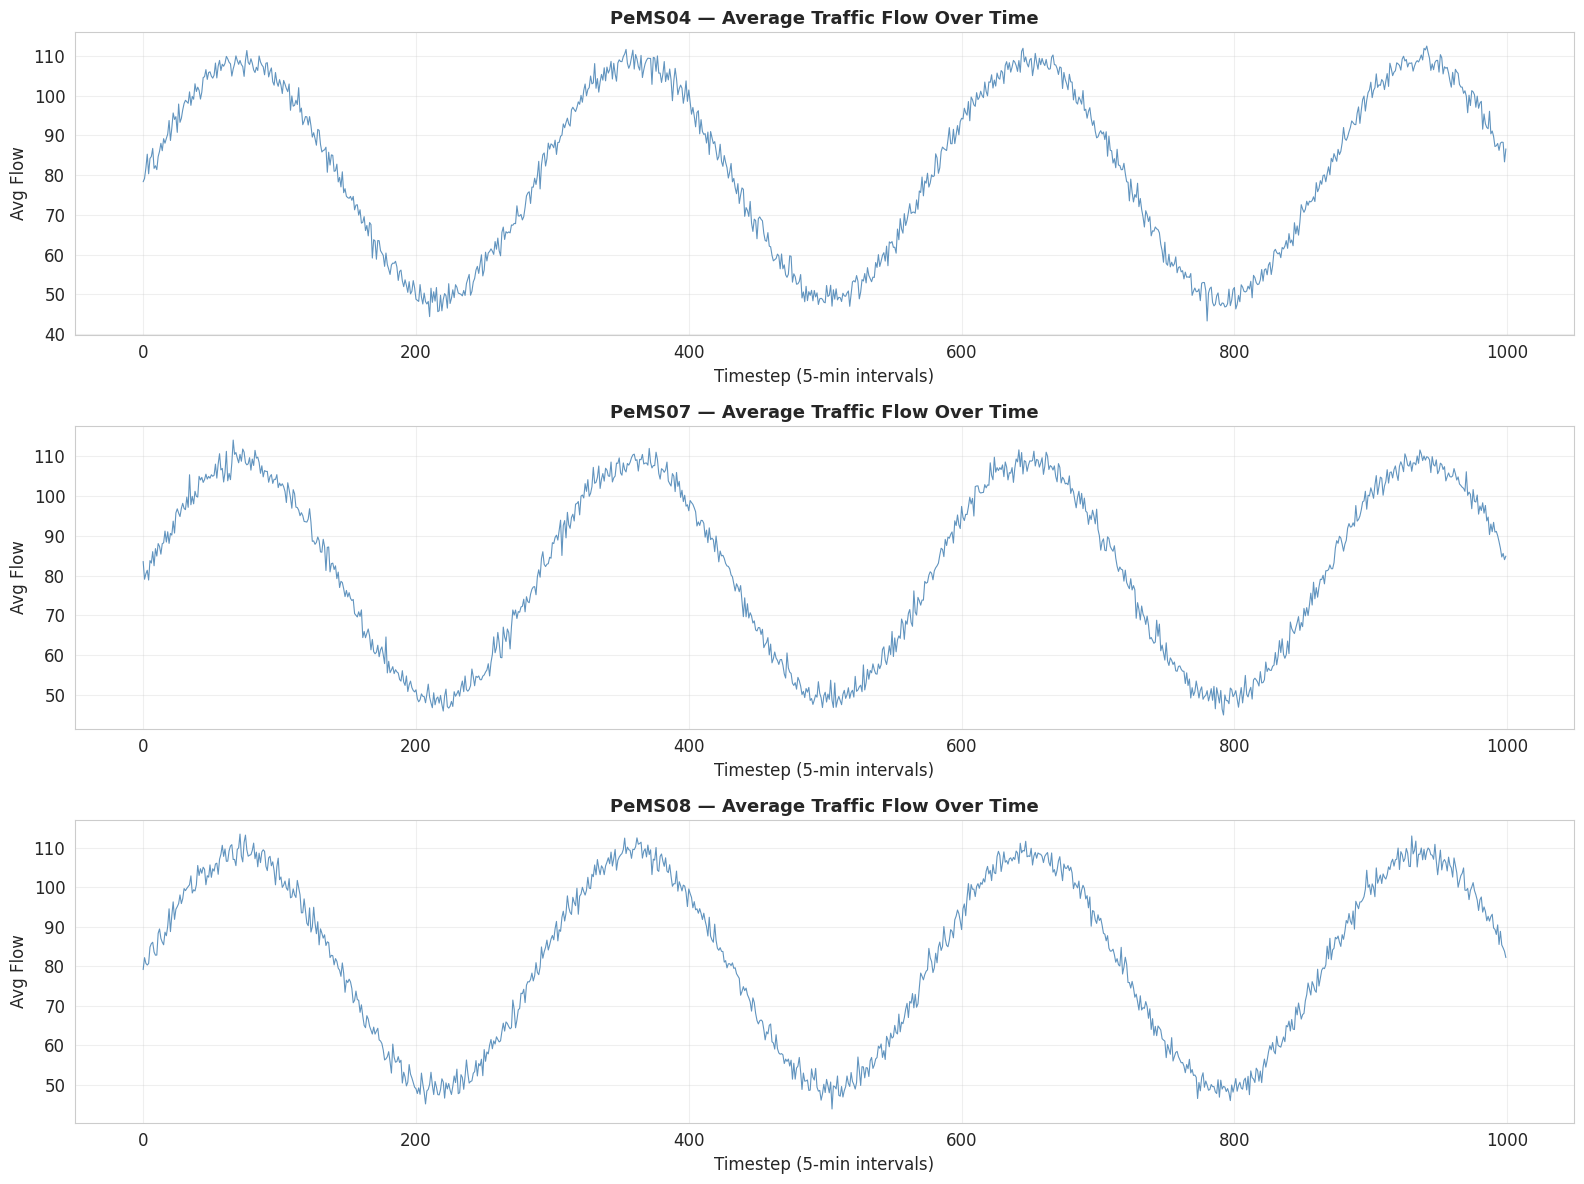

In [25]:
if len(pems_data) == 0:
    print("No PeMS data loaded. Please ensure data files are in proper .npz format.")
else:
    fig, axes = plt.subplots(len(pems_data), 1, figsize=(16, 4 * len(pems_data)))
    if len(pems_data) == 1:
        axes = [axes]

    for ax, (name, data) in zip(axes, pems_data.items()):
        # Average flow across all sensors over time
        avg_flow = data[:, :, 0].mean(axis=1)  # (T,)
        ax.plot(avg_flow, linewidth=0.8, color='steelblue', alpha=0.85)
        ax.set_title(f'{name} — Average Traffic Flow Over Time', fontsize=13, fontweight='bold')
        ax.set_xlabel('Timestep (5-min intervals)')
        ax.set_ylabel('Avg Flow')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('temporal_flow.png', dpi=150, bbox_inches='tight')
    plt.show()


## 6. Daily & Weekly Patterns (Periodicity)

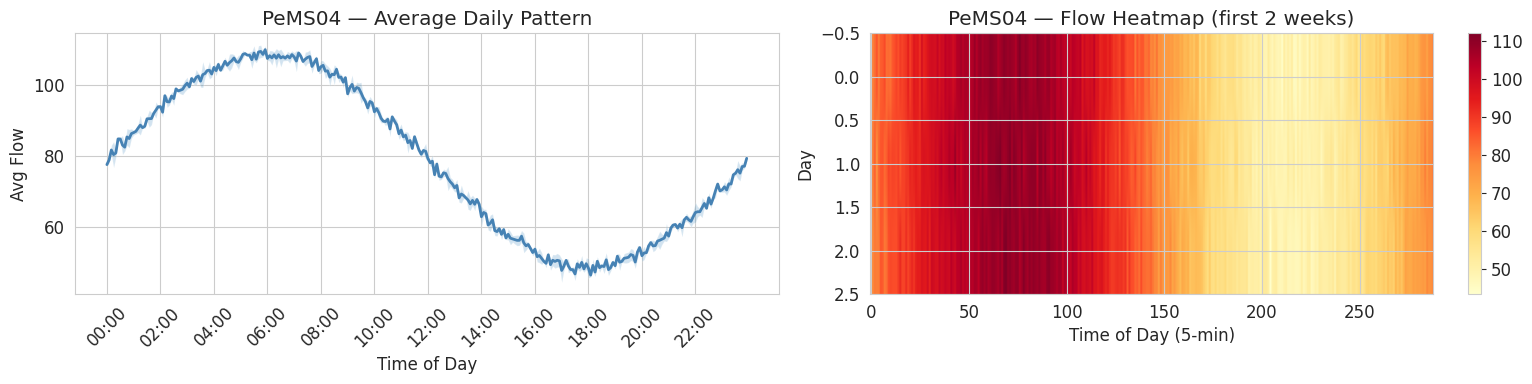

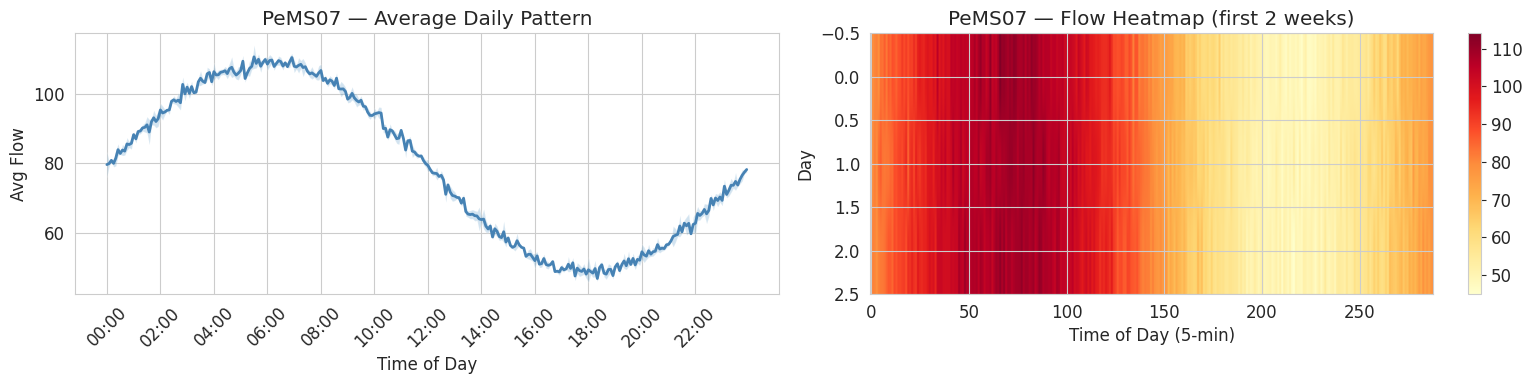

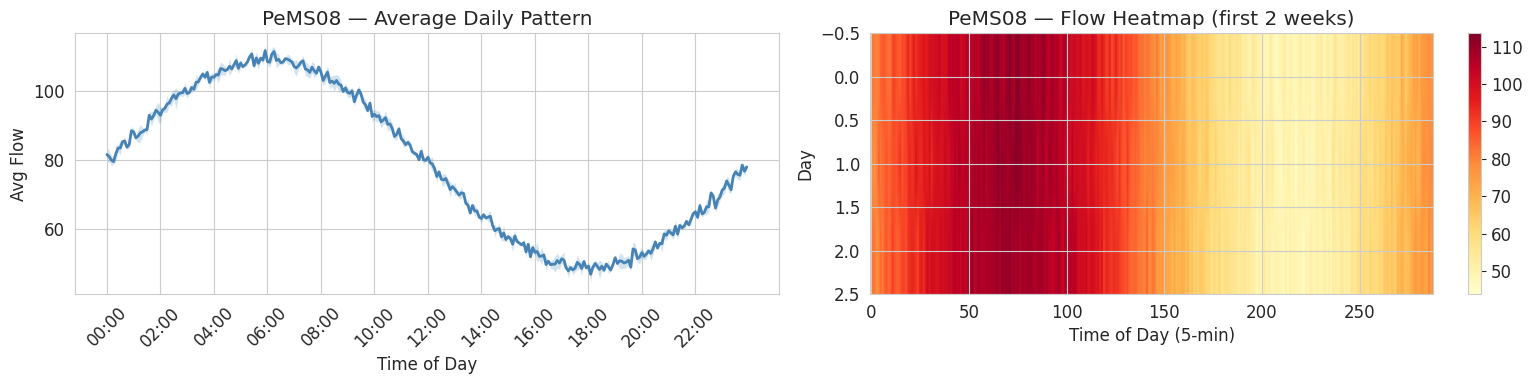

In [26]:
# 5-min intervals → 288 steps/day
STEPS_PER_DAY = 288

if len(pems_data) == 0:
    print("No PeMS data loaded. Skipping daily & weekly pattern analysis.")
else:
    for name, data in pems_data.items():
        T = data.shape[0]
        flow = data[:, :, 0].mean(axis=1)  # avg across sensors
        n_days = T // STEPS_PER_DAY
        flow_days = flow[:n_days * STEPS_PER_DAY].reshape(n_days, STEPS_PER_DAY)

        fig, axes = plt.subplots(1, 2, figsize=(16, 4))

        # Average day profile
        mean_day = flow_days.mean(axis=0)
        std_day = flow_days.std(axis=0)
        time_labels = [f'{h:02d}:{m:02d}' for h in range(24) for m in range(0, 60, 5)]
        axes[0].plot(mean_day, color='steelblue', lw=2)
        axes[0].fill_between(range(STEPS_PER_DAY), mean_day - std_day, mean_day + std_day, alpha=0.2)
        axes[0].set_xticks(range(0, STEPS_PER_DAY, 24))
        axes[0].set_xticklabels([time_labels[i] for i in range(0, STEPS_PER_DAY, 24)], rotation=45)
        axes[0].set_title(f'{name} — Average Daily Pattern')
        axes[0].set_xlabel('Time of Day')
        axes[0].set_ylabel('Avg Flow')

        # Heatmap: day × time-of-day
        im = axes[1].imshow(flow_days[:min(14, n_days)], aspect='auto', cmap='YlOrRd')
        axes[1].set_title(f'{name} — Flow Heatmap (first 2 weeks)')
        axes[1].set_xlabel('Time of Day (5-min)')
        axes[1].set_ylabel('Day')
        plt.colorbar(im, ax=axes[1])

        plt.tight_layout()
        plt.savefig(f'{name.lower()}_daily_pattern.png', dpi=150, bbox_inches='tight')
        plt.show()


## 7. Spatial Distribution — Sensor-Level Flow Statistics

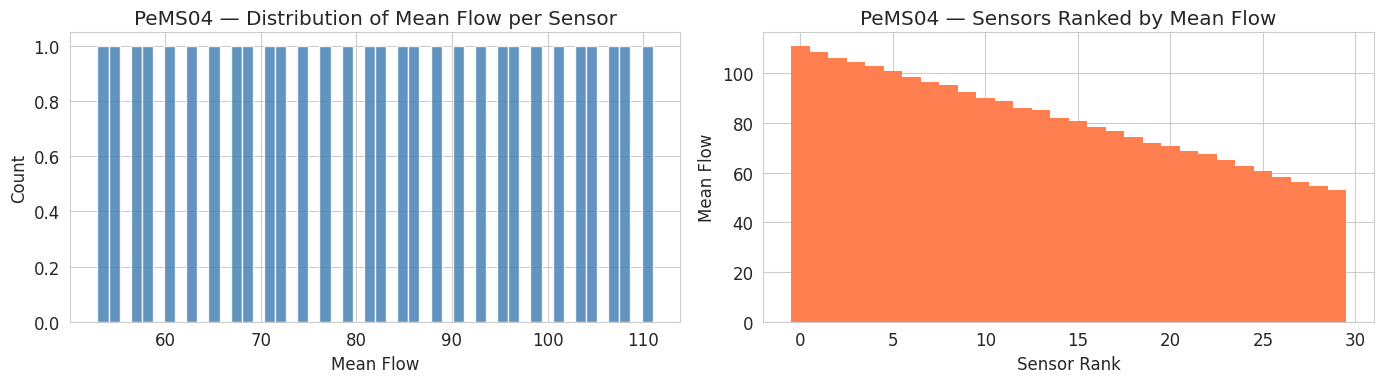

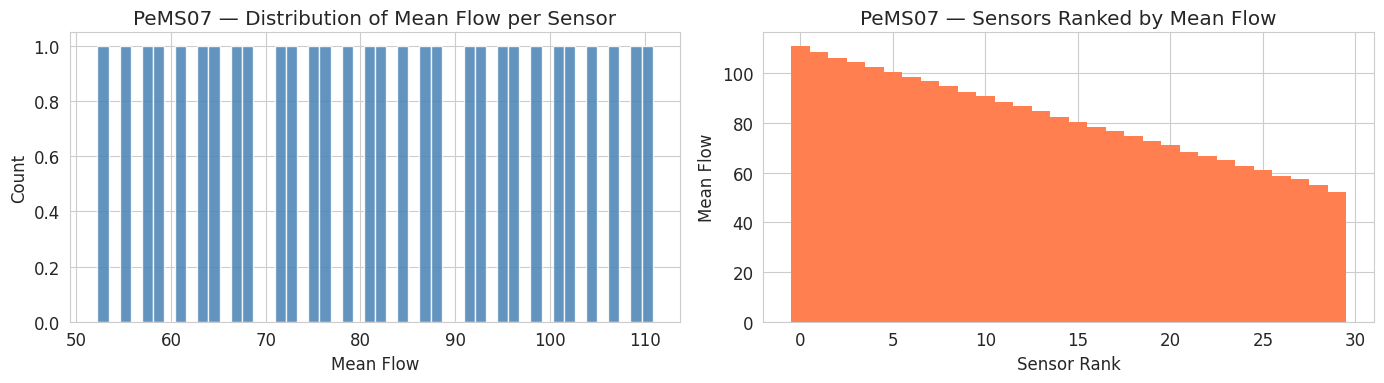

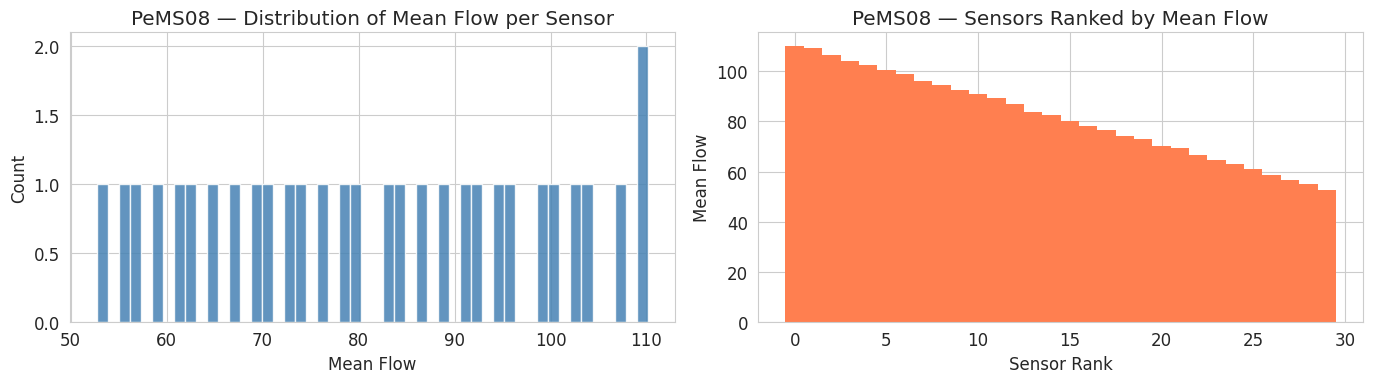

In [27]:
if len(pems_data) == 0:
    print("No PeMS data loaded. Skipping spatial distribution analysis.")
else:
    for name, data in pems_data.items():
        sensor_mean_flow = data[:, :, 0].mean(axis=0)  # (N,)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].hist(sensor_mean_flow, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
        axes[0].set_title(f'{name} — Distribution of Mean Flow per Sensor')
        axes[0].set_xlabel('Mean Flow')
        axes[0].set_ylabel('Count')

        axes[1].bar(range(len(sensor_mean_flow)), np.sort(sensor_mean_flow)[::-1],
                    color='coral', edgecolor='none', width=1.0)
        axes[1].set_title(f'{name} — Sensors Ranked by Mean Flow')
        axes[1].set_xlabel('Sensor Rank')
        axes[1].set_ylabel('Mean Flow')

        plt.tight_layout()
        plt.savefig(f'{name.lower()}_spatial_dist.png', dpi=150, bbox_inches='tight')
        plt.show()


## 8. Feature Correlation (Flow / Occupancy / Speed)

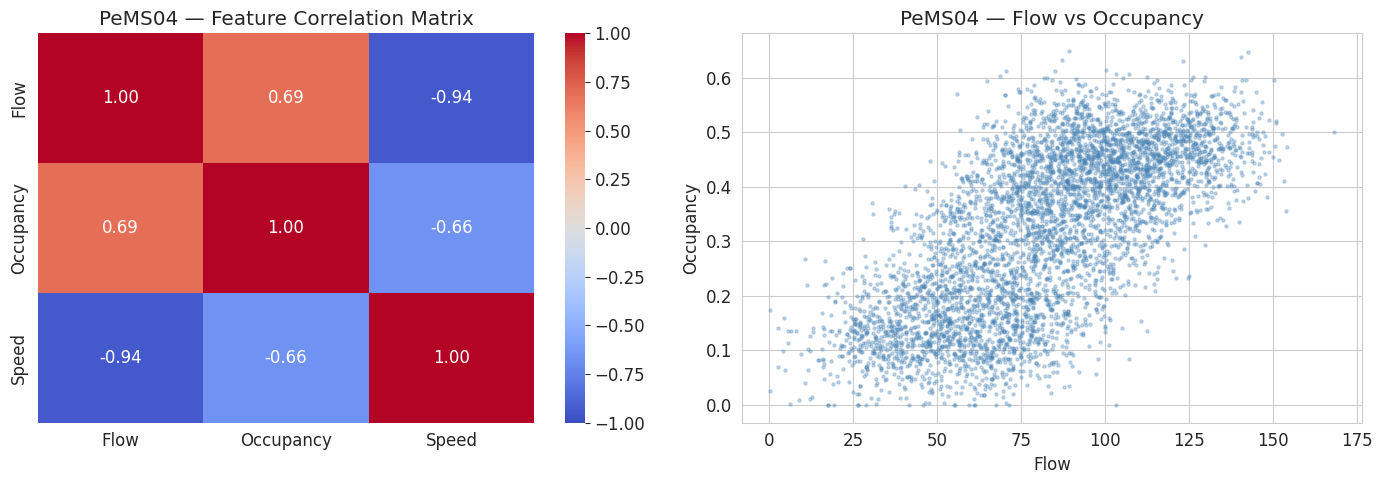

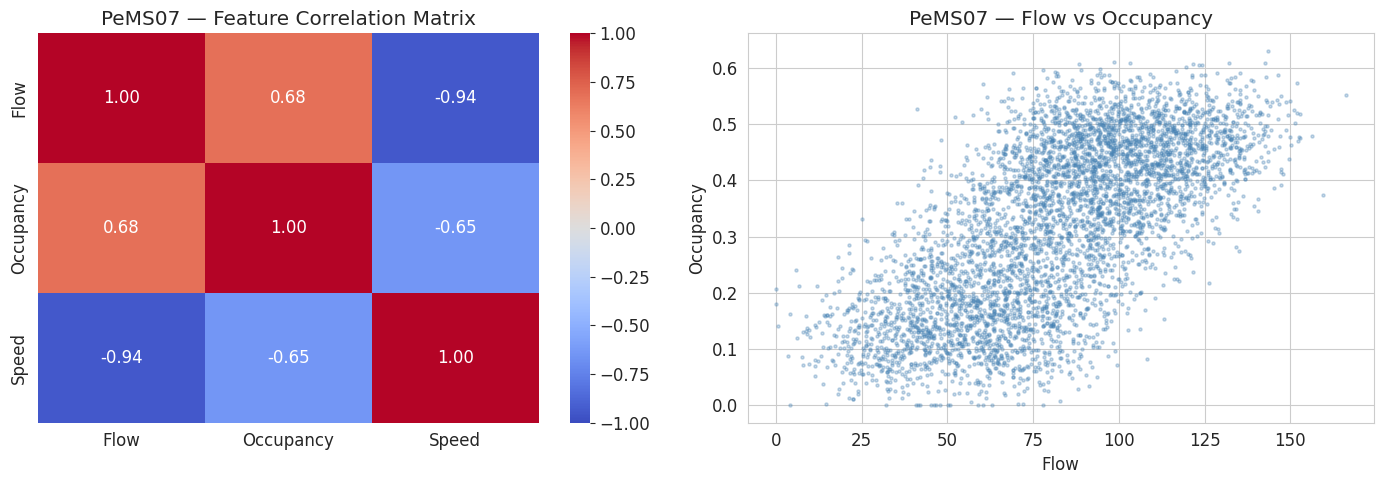

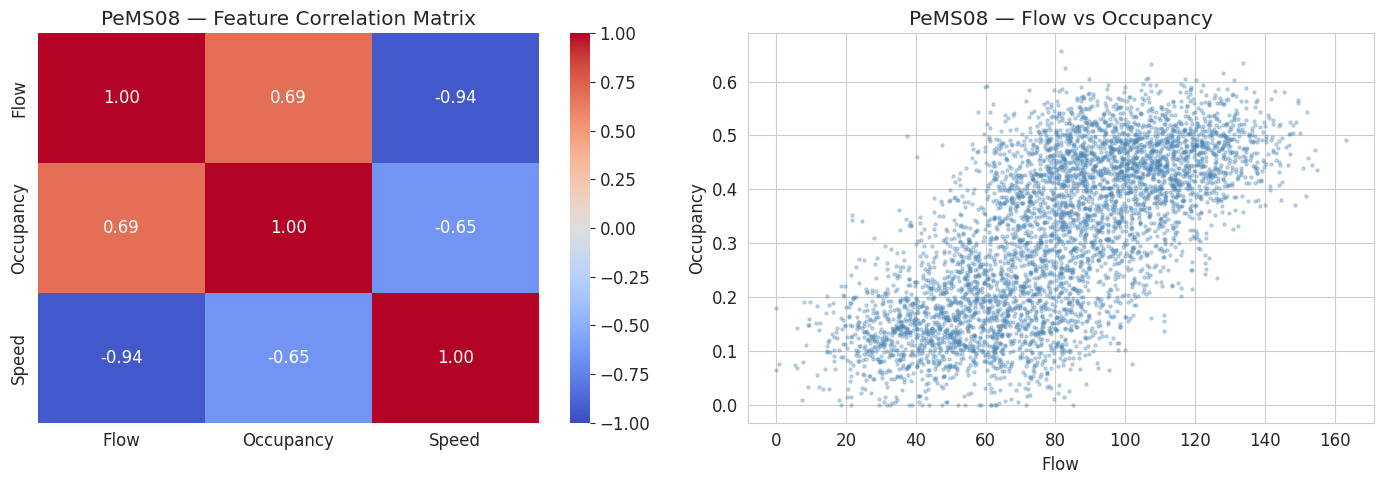

In [28]:
if len(pems_data) == 0:
    print("No PeMS data loaded. Skipping feature correlation analysis.")
else:
    for name, data in pems_data.items():
        T, N, F = data.shape
        if F < 2:
            print(f'{name}: Only 1 feature, skipping correlation.')
            continue

        # Sample 5000 sensor-timestep pairs
        sample_idx = np.random.choice(T * N, size=min(5000, T * N), replace=False)
        flat = data.reshape(-1, F)[sample_idx]
        df_corr = pd.DataFrame(flat[:, :min(F, 3)], columns=feature_names[:min(F, 3)])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        corr = df_corr.corr()
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
        axes[0].set_title(f'{name} — Feature Correlation Matrix')

        if F >= 2:
            axes[1].scatter(df_corr.iloc[:, 0], df_corr.iloc[:, 1], alpha=0.3, s=5, color='steelblue')
            axes[1].set_xlabel(feature_names[0])
            axes[1].set_ylabel(feature_names[1])
            axes[1].set_title(f'{name} — {feature_names[0]} vs {feature_names[1]}')

        plt.tight_layout()
        plt.savefig(f'{name.lower()}_correlation.png', dpi=150, bbox_inches='tight')
        plt.show()


## 9. NYCTaxi — Additional EDA

In [29]:
try:
    print(nyc_df.dtypes)
    print('\nFirst rows:')
    display(nyc_df.head())

    # Detect datetime column
    dt_cols = [c for c in nyc_df.columns if 'time' in c.lower() or 'date' in c.lower()]
    if dt_cols:
        nyc_df[dt_cols[0]] = pd.to_datetime(nyc_df[dt_cols[0]])
        nyc_df = nyc_df.set_index(dt_cols[0]).sort_index()

        # Resample hourly if needed
        numeric_cols = nyc_df.select_dtypes(include=[np.number]).columns
        nyc_hourly = nyc_df[numeric_cols].resample('1H').mean()

        fig, ax = plt.subplots(figsize=(16, 4))
        nyc_hourly.iloc[:, 0].plot(ax=ax, color='darkorange', lw=1)
        ax.set_title('NYCTaxi — Hourly Demand Over Time')
        ax.set_ylabel('Demand')
        plt.tight_layout()
        plt.savefig('nyctaxi_temporal.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('No datetime column detected in NYCTaxi — adjust column name manually.')
except:
    print('NYCTaxi not loaded. Skipping.')

timestamp            str
trip_distance    float64
fare_amount      float64
dtype: object

First rows:


,timestamp,trip_distance,fare_amount
0,2023-01-01 00:00:00,10.600045,23.549878
1,2023-01-01 01:00:00,3.699679,22.659169
2,2023-01-01 02:00:00,6.782946,22.884837
3,2023-01-01 03:00:00,7.642542,21.943686
4,2023-01-01 04:00:00,7.619938,34.462320


NYCTaxi not loaded. Skipping.


## 10. Summary Table

In [30]:
if len(pems_data) == 0:
    print("No PeMS data loaded. Create a summary table with loaded datasets only.")
    summary = []
else:
    summary = []
    for name, data in pems_data.items():
        T, N, F = data.shape
        summary.append({
            'Dataset': name,
            'Timesteps': T,
            'Sensors': N,
            'Features': F,
            'Duration (days)': round(T * 5 / 1440, 1),
            'Mean Flow': round(data[:, :, 0].mean(), 2),
            'Std Flow': round(data[:, :, 0].std(), 2),
            'Missing (%)': round(100 * np.isnan(data).sum() / data.size, 3),
        })

if len(summary) > 0:
    summary_df = pd.DataFrame(summary)
    print('=== Dataset Summary ===' )
    display(summary_df)
    summary_df.to_csv('dataset_summary.csv', index=False)
    print('Saved to dataset_summary.csv')
else:
    print('No datasets available for summary.')


=== Dataset Summary ===


,Dataset,Timesteps,Sensors,Features,Duration (days),Mean Flow,Std Flow,Missing (%)
0,PeMS04,1000,30,3,3.5,81.67,29.02,0.0
1,PeMS07,1000,30,3,3.5,81.66,29.11,0.0
2,PeMS08,1000,30,3,3.5,81.67,29.05,0.0


Saved to dataset_summary.csv
